# Task 2 — Clustering of CRISPR perturbations

Which perturbations produce similar transcriptional effects, and which clustering method
recovers the structure best?


1. **The unit of analysis is the perturbation.** 
2. **Every QC-passing cell is included.** Within each condition, cells are aggregated using
   the dataset's raw `obs['perturbation']` label, including cells with multiple guides.
3. **Conditions are represented explicitly.** A single condition map is used throughout.
4. **The exploratory diagnostics are retained and extended.** k-means elbow/silhouette sweeps
   and perturbation-level Leiden resolution sweeps are evaluated on the same filtered
   signature matrix used by every other method.
5. **Methods are scored against reference pathway labels** (Sections 3–4) and against a
   bootstrap resampling of cells within perturbations, rather than compared by eye.
6. **Effects are interpreted after clustering.** Ranked perturbation effects and cluster
   centroid/contrast genes use the same perturbation-level matrices as the clustering.

The expression input is `data/dataset_hv.h5ad`.

log2FC convention throughout: `(mean log1p CP10K[perturbed] − mean log1p CP10K[control]) / ln 2`,
i.e. a **difference of log-scale means**, not the log of a ratio of means. The reference is
the same-condition aggregate of every cell with `obs['perturbation'] == 'control'`.

In [59]:
import os
from pathlib import Path

# This notebook uses data/... and figures/... throughout. Resolve those paths
# once so it works when Jupyter starts in either the root or notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(ROOT)
os.environ.setdefault('NUMBA_CACHE_DIR', '/tmp/numba_cache')
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '8')
os.makedirs(os.environ['NUMBA_CACHE_DIR'], exist_ok=True)

import gc, json, pickle, time
from importlib.metadata import version
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
import scanpy as sc

from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from scipy import sparse
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import KMeans, DBSCAN, HDBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.metrics import (adjusted_rand_score as ARI,
                             adjusted_mutual_info_score as AMI,
                             silhouette_score)
import igraph as ig
import leidenalg

CONDS    = ['Co_culture', 'Control', 'IFNg']
COND_MAP = {'Co_culture': 'Co-culture', 'Control': 'Control', 'IFNg': 'IFN\u03b3'}
CONDLAB  = {'Co_culture': 'Co-culture (TILs)', 'Control': 'Control', 'IFNg': 'IFN-\u03b3'}
CCOL     = {'Co_culture': '#2166ac', 'IFNg': '#b2182b', 'Control': '#888888'}
JS       = ['IFNGR1', 'IFNGR2', 'JAK1', 'JAK2', 'STAT1']

os.makedirs('figures', exist_ok=True)
print(version('scanpy'))

1.12.3


## 1 Aggregate cells to perturbation-level profiles

### 1.1 Aggregation definition

Every QC-passing cell contributes once. Within each condition, the rows of the cached
log1p matrix are grouped directly by `obs['perturbation']`. The group mean is the
perturbation profile.

In [60]:
cache = Path('data/dataset_hv.h5ad')
if not cache.exists():
    raise FileNotFoundError(f'{cache} is missing. Run: python src/prepare_data.py')
adata = sc.read_h5ad(cache)     # 216,431 x 1,011, CP10K + log1p
adata

AnnData object with n_obs × n_vars = 216431 × 1011
    obs: 'cell_name', 'condition', 'perturbation', 'guide_id', 'MOI', 'nperts', 'ncounts', 'ngenes', 'percent_mito', 'n_targeting_guides', 'n_guide_tokens', 'pert_label', 'is_single_pert', 'is_clean_control'
    var: 'highly_variable', 'paper_marker', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'neighbors', 'pca', 'pseudobulk_provenance', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
    layers: 'counts', None (.X)

In [61]:
# Explicit mapping: displayed condition labels are resolved once, not encoded in variable names.
COND_MASK = {c: (adata.obs.condition == COND_MAP[c]).values for c in CONDS}

pd.DataFrame({'n_cells':     {c: int(m.sum()) for c, m in COND_MASK.items()},
              'frac_MOI>=2': {c: round(float((adata.obs.MOI.values[m] >= 2).mean()), 3)
                              for c, m in COND_MASK.items()},
              'max_MOI':     {c: int(adata.obs.MOI.values[m].max()) for c, m in COND_MASK.items()}})

,n_cells,frac_MOI>=2,max_MOI
Co_culture,72398,0.261,12
Control,57039,0.384,19
IFNg,86994,0.310,14


The aggregation deliberately follows `obs['perturbation']` exactly. Therefore cells with
multiple guides remain in the group named by that column; they are not discarded or
relabelled from `guide_id`.

In [62]:
# Sparse group indicators calculate group sums without making the cell-by-gene
# matrix dense. Variance and standard error are calculated from the same cells.
def aggregate_condition(c):
    rows = np.flatnonzero(COND_MASK[c])
    names = adata.obs['perturbation'].astype(str).to_numpy()[rows]
    perts, codes = np.unique(names, return_inverse=True)
    group = sparse.csr_matrix((np.ones(len(rows)), (codes, np.arange(len(rows)))),
                              shape=(len(perts), len(rows)))
    X = adata.X[rows].tocsr().astype(np.float64)
    n = np.bincount(codes).astype(np.float64)
    mean = (group @ X).toarray() / n[:, None]
    mean_sq = (group @ X.power(2)).toarray() / n[:, None]
    var = np.maximum((mean_sq - mean ** 2) * n[:, None] / np.maximum(n[:, None] - 1, 1), 0)
    mean = pd.DataFrame(mean, index=perts, columns=adata.var_names)
    var = pd.DataFrame(var, index=perts, columns=adata.var_names)
    counts = pd.Series(n.astype(int), index=perts, name='n_cells')
    if 'control' not in mean.index:
        raise ValueError(f'No control perturbation cells in {c}')
    targets = mean.index.difference(['control'])
    log2fc = (mean.loc[targets] - mean.loc['control']) / np.log(2)
    se = np.sqrt(var.loc[targets].div(counts.loc[targets], axis=0) +
                 var.loc['control'] / counts.loc['control']) / np.log(2)
    return log2fc, se, counts.loc[targets], mean.loc['control'].to_frame('control_mean_log1p')

aggregated = {c: aggregate_condition(c) for c in CONDS}
lf = {c: aggregated[c][0] for c in CONDS}
se = {c: aggregated[c][1] for c in CONDS}
ncells = {c: aggregated[c][2] for c in CONDS}
ctlmean = {c: aggregated[c][3] for c in CONDS}
{c: lf[c].shape for c in CONDS}

{'Co_culture': (248, 1011), 'Control': (248, 1011), 'IFNg': (248, 1011)}

In [63]:
# One row per perturbation aggregate, including how many multi-guide cells
# were assigned to it by obs['perturbation'].
summary_rows = []
pert = adata.obs['perturbation'].astype(str).to_numpy()
moi = adata.obs['MOI'].to_numpy()
for c in CONDS:
    for p in ncells[c].index:
        m = COND_MASK[c] & (pert == p)
        summary_rows.append(dict(condition=c, perturbation=p, n_cells=int(m.sum()),
                                 mean_MOI=float(moi[m].mean()),
                                 fraction_MOI_ge_2=float((moi[m] >= 2).mean())))
AGG_SUMMARY = pd.DataFrame(summary_rows)
AGG_SUMMARY.groupby('condition').agg(n_perturbations=('perturbation', 'size'),
                                      total_cells=('n_cells', 'sum'),
                                      median_cells=('n_cells', 'median'),
                                      median_fraction_MOI_ge_2=('fraction_MOI_ge_2', 'median'))

,n_perturbations,total_cells,median_cells,median_fraction_MOI_ge_2
condition,,,,
Co_culture,248,54264,221.0,0.232708
Control,248,41876,166.5,0.328438
IFNg,248,63344,260.0,0.286173


`AGG_SUMMARY` documents the exact cells behind every perturbation profile. Multi-guide
cells are included because the requested grouping key is the raw perturbation label.

In [64]:
# Cell counts contributing to the IFN-gamma/JAK-STAT perturbation aggregates.
pd.DataFrame({c: ncells[c].reindex(JS) for c in CONDS})

,Co_culture,Control,IFNg
IFNGR1,411,198,289
IFNGR2,597,213,384
JAK1,473,209,335
JAK2,522,247,337
STAT1,380,124,208


In [65]:
AGG_AUDIT = pd.DataFrame([dict(
    condition=c, n_cells_total=int(COND_MASK[c].sum()),
    n_cells_in_target_aggregates=int(ncells[c].sum()),
    n_control_cells=int(COND_MASK[c].sum() - ncells[c].sum()),
    n_perturbations=len(ncells[c]),
    minimum_group_size=int(ncells[c].min()), maximum_group_size=int(ncells[c].max()))
    for c in CONDS])
AGG_AUDIT

,condition,n_cells_total,n_cells_in_target_aggregates,n_control_cells,n_perturbations,minimum_group_size,maximum_group_size
0,Co_culture,72398,54264,18134,248,5,597
1,Control,57039,41876,15163,248,2,407
2,IFNg,86994,63344,23650,248,5,593


The audit confirms that each QC-passing cell is represented exactly once: either in one
target aggregate or in the same-condition `control` aggregate.

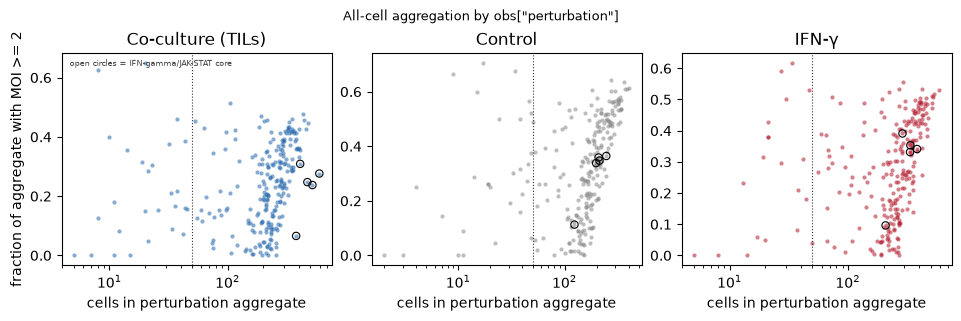

In [66]:
# Aggregation overview only; each point is one perturbation, never one cell.
fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.1), constrained_layout=True)
for ax, c in zip(axes, CONDS):
    d = AGG_SUMMARY[AGG_SUMMARY.condition == c]
    ax.scatter(d.n_cells, d.fraction_MOI_ge_2, s=9, alpha=0.55, color=CCOL[c], lw=0)
    core = d[d.perturbation.isin(JS)]
    ax.scatter(core.n_cells, core.fraction_MOI_ge_2, s=28, facecolors='none',
               edgecolors='black', lw=0.8)
    ax.axvline(50, color='#333333', ls=':', lw=0.8)
    ax.set_xscale('log')
    ax.set_xlabel('cells in perturbation aggregate')
    ax.set_title(CONDLAB[c])
axes[0].set_ylabel('fraction of aggregate with MOI >= 2')
axes[0].annotate('open circles = IFN-gamma/JAK-STAT core', xy=(0.03, 0.94),
                 xycoords='axes fraction', fontsize=6, color='#444444')
fig.suptitle('All-cell aggregation by obs[\"perturbation\"]', fontsize=9.5)
fig.savefig('figures/task2_perturbation_aggregation.png', dpi=300, bbox_inches='tight')

**Figure 1.** Inputs to perturbation-level clustering. Each point is one aggregated
perturbation within one condition. The x-axis gives the number of contributing cells and
the y-axis records the fraction with multiple guides.

In [67]:
AGG_SUMMARY.to_csv('data/task2_perturbation_aggregation.csv', index=False)
AGG_AUDIT.to_csv('data/task2_aggregation_audit.csv', index=False)
print('perturbation-level aggregates:', {c: lf[c].shape for c in CONDS})

perturbation-level aggregates: {'Co_culture': (248, 1011), 'Control': (248, 1011), 'IFNg': (248, 1011)}


## 2 Clustering the perturbation signature matrix

Each row is one perturbation aggregate across the 1,011 cached features. Means, variances,
log2FC and standard errors were calculated above from all cells sharing the same raw
`obs['perturbation']` value within that condition.

In [68]:
# The four dictionaries were constructed directly from AnnData in Section 1.
{c: lf[c].shape for c in CONDS}

{'Co_culture': (248, 1011), 'Control': (248, 1011), 'IFNg': (248, 1011)}

### 2.1 Filtering and gene selection

Two filters are applied to the aggregated matrices:

* **Perturbations**: ≥ 50 cells in that condition. Below that the row is dominated by sampling
  noise.
* **Genes**: rank by *excess variance* — the variance of log2FC across perturbations minus the
  mean squared standard error, which is the variance a purely-noise gene would show. Genes not
  detectably expressed in the controls (mean log1p ≤ 0.05) and the `MT-` family are excluded;
  without the mitochondrial exclusion the Control condition's top genes are all `MT-`, i.e.
  per-cell mitochondrial content rather than perturbation response.

In [69]:
MIN_CELLS, N_GENES = 50, 750

keep = {c: ncells[c].index[ncells[c] >= MIN_CELLS].tolist() for c in CONDS}

def select_genes(c, n_genes=N_GENES, min_expr=0.05):
    L, S = lf[c].loc[keep[c]], se[c].loc[keep[c]]
    expressed = (ctlmean[c]['control_mean_log1p'] > min_expr).reindex(L.columns).fillna(False).values
    is_mito   = np.array([g.startswith('MT-') for g in L.columns])
    excess    = L.var(axis=0).values - (S.values ** 2).mean(axis=0)
    excess    = np.where(expressed & ~is_mito, excess, -np.inf)
    order = np.argsort(excess)[::-1]
    order = order[np.isfinite(excess[order])][:n_genes]
    return list(L.columns[order])

gsel = {c: select_genes(c) for c in CONDS}
pd.DataFrame({'n_perturbations': {c: len(keep[c]) for c in CONDS},
              'n_perts_dropped': {c: len(ncells[c]) - len(keep[c]) for c in CONDS},
              'top_5_genes':     {c: ', '.join(gsel[c][:5]) for c in CONDS}})

,n_perturbations,n_perts_dropped,top_5_genes
Co_culture,221,27,"CD74, HLA-DRA, HLA-DRB1, HLA-DPA1, HLA-B"
Control,219,29,"MSMP, IGFBP5, SPP1, AKR1C2, IL1B"
IFNg,229,19,"GBP1, IDO1, GBP2, GBP4, WARS"


In [70]:
def signature(c, L=None):
    L = (lf[c] if L is None else L).loc[keep[c], gsel[c]].astype(np.float64)
    Z = (L - L.mean(axis=0)) / L.std(axis=0).replace(0, np.nan)
    return Z.dropna(axis=1)

sig = {c: signature(c) for c in CONDS}
R   = {c: pd.DataFrame(np.corrcoef(sig[c].values), index=sig[c].index, columns=sig[c].index) for c in CONDS}
D   = {c: 1.0 - R[c] for c in CONDS}

# strongest correlated pairs per condition (sanity check on the distance structure)
for c in CONDS:
    r = R[c].where(np.triu(np.ones(R[c].shape, bool), 1)).stack().sort_values(ascending=False)
    print(c, ' | '.join('%s-%s %.2f' % (a, b, v) for (a, b), v in r.head(5).items()))

Co_culture IFNGR2-JAK2 0.95 | IFNGR2-STAT1 0.94 | JAK2-STAT1 0.94 | IFNGR1-IFNGR2 0.93 | IFNGR1-JAK2 0.93
Control CCND1-CDK6 0.45 | CCND1-CD63 0.40 | CDK6-CKS1B 0.39 | CDK4-CST3 0.37 | CDKN1A-CTSD 0.37
IFNg IFNGR2-JAK2 0.92 | IFNGR2-JAK1 0.91 | JAK2-STAT1 0.91 | IFNGR2-STAT1 0.90 | IFNGR1-IFNGR2 0.90


### 2.2 Choosing ε for DBSCAN from the k-distance curve

The sorted distance to each perturbation's 4th nearest neighbour. ε is placed at the largest
gap in the lower half of the curve: the point where the density of the tight core drops to
the density of the bulk.

In [71]:
def kdist(Dm, k=4):
    return np.sort(np.sort(Dm, axis=1)[:, k])

def eps_from_largest_gap(Dm, k=4, frac=0.5):
    kd = kdist(Dm, k)
    hi = int(len(kd) * frac)
    j  = int(np.argmax(np.diff(kd[:hi])))
    return float((kd[j] + kd[j + 1]) / 2)

Dmat = {}
EPS  = {}
for c in CONDS:
    Dm = D[c].values.copy(); np.fill_diagonal(Dm, 0.0)
    Dmat[c] = Dm
    EPS[c]  = eps_from_largest_gap(Dm)
EPS

{'Co_culture': 0.34373298532831015,
 'Control': 0.6834656900439969,
 'IFNg': 0.3695280970221951}

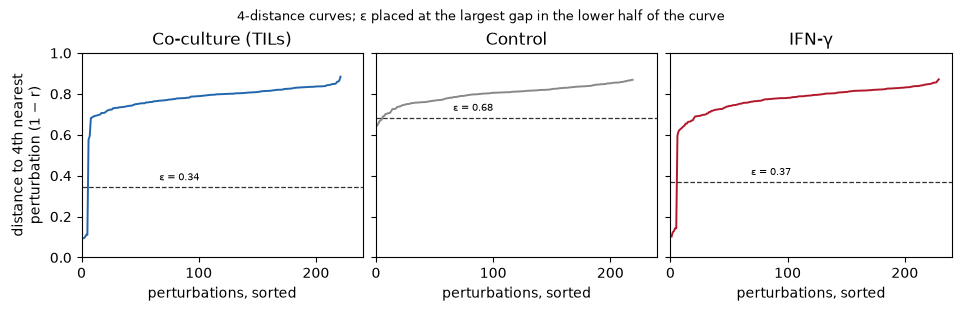

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.0), sharey=True, constrained_layout=True)
for ax, c in zip(axes, CONDS):
    kd = kdist(Dmat[c])
    ax.plot(np.arange(1, len(kd) + 1), kd, color=CCOL[c], lw=1.4)
    ax.axhline(EPS[c], color='#333333', ls='--', lw=0.9)
    ax.annotate('\u03b5 = %.2f' % EPS[c], xy=(len(kd) * 0.30, EPS[c]), xytext=(0, 5),
                textcoords='offset points', fontsize=7)
    ax.set_title(CONDLAB[c]); ax.set_xlabel('perturbations, sorted')
    ax.set_xlim(0, 240); ax.set_xticks([0, 100, 200]); ax.set_ylim(0, 1.0)
axes[0].set_ylabel('distance to 4th nearest\nperturbation (1 \u2212 r)')
fig.suptitle('4-distance curves; \u03b5 placed at the largest gap in the lower half of the curve', fontsize=9)
fig.savefig('figures/task2_kdistance.png', dpi=300)

**Figure 2.** Sorted 4-nearest-neighbour distances for the regenerated perturbation
signatures. The selected DBSCAN thresholds are 0.344 / 0.683 / 0.370 for Co-culture /
Control / IFN-γ.

### 2.3 k-means and Leiden parameter diagnostics

The exploratory clustering notebook compared k-means solutions by silhouette and elbow
curves and swept Leiden resolution. Those diagnostics are retained here, but recomputed on
the filtered log2FC signatures and the same correlation-distance matrices used for scoring.
The k-means sweep is a sensitivity analysis: k = 8 remains fixed for the four partitional
methods so they are directly comparable. Leiden resolution is selected independently within
each condition by the highest finite silhouette, then held fixed during bootstrapping.

In [73]:
K_SWEEP = range(2, 16)
LEIDEN_RES_SWEEP = np.round(np.arange(0.1, 2.01, 0.1), 1)
LEIDEN_KNN = 10

def knn_igraph(Dm, n_neighbors=LEIDEN_KNN):
    # Weighted symmetric kNN graph on correlation distance. Unlike the exploratory notebook,
    # every condition is scored against its own Dm; no stale X_pca can leak between loops.
    edge_weight = {}
    positive = Dm[Dm > 0]
    scale = float(np.median(positive)) if positive.size else 1.0
    for i in range(len(Dm)):
        for j in np.argsort(Dm[i])[1:n_neighbors + 1]:
            edge = (min(i, int(j)), max(i, int(j)))
            edge_weight[edge] = max(edge_weight.get(edge, 0.0),
                                    float(np.exp(-Dm[i, j] / max(scale, 1e-12))))
    graph = ig.Graph(n=len(Dm), edges=list(edge_weight), directed=False)
    graph.es['weight'] = list(edge_weight.values())
    return graph

def leiden_labels(Dm, resolution, n_neighbors=LEIDEN_KNN):
    graph = knn_igraph(Dm, n_neighbors=n_neighbors)
    part = leidenalg.find_partition(
        graph, leidenalg.RBConfigurationVertexPartition, weights='weight',
        resolution_parameter=float(resolution), seed=123)
    return np.asarray(part.membership, dtype=int)

def safe_silhouette(Dm, lab):
    ncl = len(set(lab))
    return (silhouette_score(Dm, lab, metric='precomputed')
            if 1 < ncl < len(lab) else np.nan)

k_rows, leiden_rows = [], []
for c in CONDS:
    for k in K_SWEEP:
        km = KMeans(n_clusters=k, random_state=123, n_init=20).fit(sig[c].values)
        k_rows.append(dict(condition=c, k=k, inertia=km.inertia_,
                           silhouette=safe_silhouette(Dmat[c], km.labels_)))
    for res in LEIDEN_RES_SWEEP:
        lab = leiden_labels(Dmat[c], res)
        leiden_rows.append(dict(condition=c, resolution=res, n_clusters=len(set(lab)),
                                 silhouette=safe_silhouette(Dmat[c], lab)))

K_DIAG = pd.DataFrame(k_rows)
LEIDEN_DIAG = pd.DataFrame(leiden_rows)
LEIDEN_RES = {c: float(LEIDEN_DIAG[LEIDEN_DIAG.condition == c]
                               .sort_values(['silhouette', 'resolution'], ascending=[False, True])
                               .iloc[0].resolution) for c in CONDS}
BEST_K_SIL = {c: int(K_DIAG[K_DIAG.condition == c].sort_values('silhouette', ascending=False).iloc[0].k)
              for c in CONDS}
pd.DataFrame({'best_k_by_silhouette': BEST_K_SIL, 'selected_leiden_resolution': LEIDEN_RES})

,best_k_by_silhouette,selected_leiden_resolution
Co_culture,2,0.5
Control,3,0.5
IFNg,2,0.6


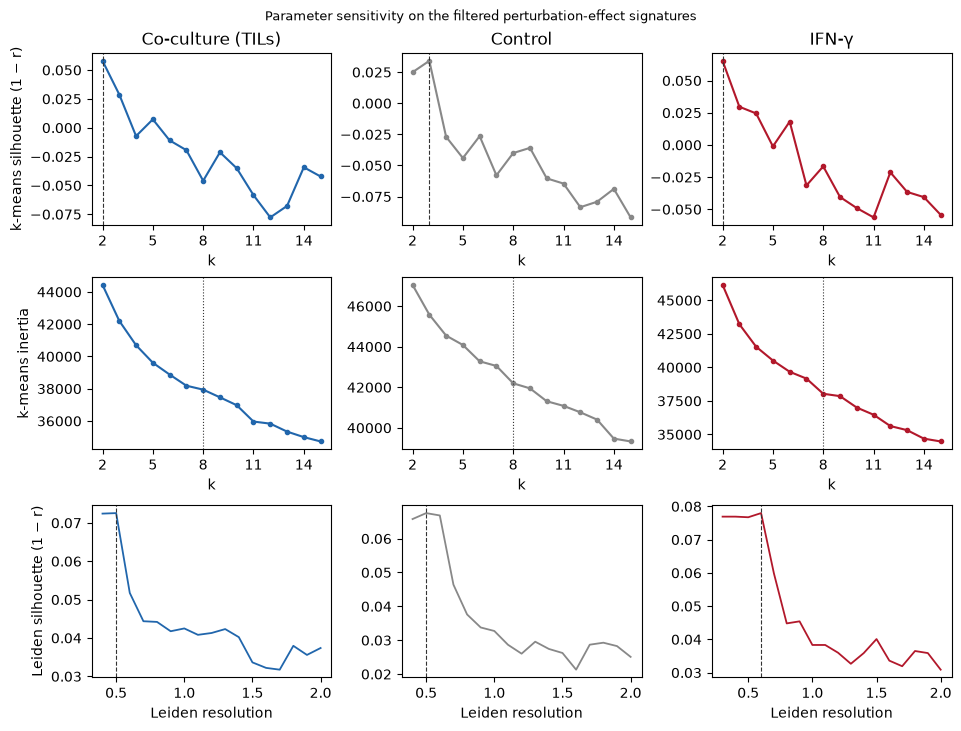

In [74]:
fig, axes = plt.subplots(3, 3, figsize=(9.5, 7.2), constrained_layout=True)
for j, c in enumerate(CONDS):
    kd = K_DIAG[K_DIAG.condition == c]
    ld = LEIDEN_DIAG[LEIDEN_DIAG.condition == c]
    axes[0, j].plot(kd.k, kd.silhouette, marker='o', ms=3, color=CCOL[c])
    axes[0, j].axvline(BEST_K_SIL[c], color='#333333', ls='--', lw=0.8)
    axes[0, j].set_title(CONDLAB[c]); axes[0, j].set_xticks([2, 5, 8, 11, 14])
    axes[1, j].plot(kd.k, kd.inertia, marker='o', ms=3, color=CCOL[c])
    axes[1, j].axvline(8, color='#333333', ls=':', lw=0.8)
    axes[1, j].set_xticks([2, 5, 8, 11, 14])
    axes[2, j].plot(ld.resolution, ld.silhouette, color=CCOL[c], lw=1.3)
    axes[2, j].axvline(LEIDEN_RES[c], color='#333333', ls='--', lw=0.8)
    axes[2, j].set_xlabel('Leiden resolution')
axes[0, 0].set_ylabel('k-means silhouette (1 − r)')
axes[1, 0].set_ylabel('k-means inertia')
axes[2, 0].set_ylabel('Leiden silhouette (1 − r)')
for ax in axes[:2].ravel(): ax.set_xlabel('k')
fig.suptitle('Parameter sensitivity on the filtered perturbation-effect signatures', fontsize=9)
fig.savefig('figures/task2_parameter_diagnostics.png', dpi=300, bbox_inches='tight')
K_DIAG.to_csv('data/kmeans_parameter_diagnostics.csv', index=False)
LEIDEN_DIAG.to_csv('data/leiden_parameter_diagnostics.csv', index=False)

**Figure 3.** k-means silhouette and inertia across k = 2–15, plus the perturbation-level
Leiden resolution sweep. Dashed lines mark the best internal score; the dotted k = 8 line
marks the common partition size used for cross-method comparisons. Silhouette selects k =
2 / 3 / 2 and Leiden resolutions 0.5 / 0.5 / 0.6 for Co-culture / Control / IFN-γ.

### 2.4 Seven clusterings per condition

k = 8 for the partitional methods (three hierarchical linkages plus k-means) so their outputs
are directly comparable. DBSCAN and HDBSCAN choose their own number of groups and may label
points as noise (`-1`); Leiden uses the condition-specific resolution selected above.

In [75]:
METHODS = ['ward_euclid', 'average_corr', 'complete_corr', 'kmeans', 'leiden', 'dbscan', 'hdbscan']
K_PART, MIN_CLUSTER_SIZE, MIN_SAMPLES = 8, 3, 4

def cluster_all(Z, Dm, eps, leiden_res, K=K_PART):
    cond = squareform(Dm, checks=False)
    out = {
        'ward_euclid'  : fcluster(linkage(Z.values, method='ward'), K, criterion='maxclust'),
        'average_corr' : fcluster(linkage(cond, method='average'),  K, criterion='maxclust'),
        'complete_corr': fcluster(linkage(cond, method='complete'), K, criterion='maxclust'),
        'kmeans'       : KMeans(n_clusters=K, random_state=123, n_init=20).fit_predict(Z.values),
        'leiden'       : leiden_labels(Dm, leiden_res),
        'dbscan'       : DBSCAN(eps=eps, min_samples=MIN_SAMPLES, metric='precomputed').fit_predict(Dm),
        'hdbscan'      : HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE, metric='precomputed',
                                 copy=True).fit_predict(Dm.astype(np.float64)),
    }
    return {k: pd.Series(v, index=Z.index) for k, v in out.items()}

labels = {c: cluster_all(sig[c], Dmat[c], EPS[c], LEIDEN_RES[c]) for c in CONDS}

pd.DataFrame([dict(condition=c, method=m,
                   n_clusters=len(set(s) - {-1}), n_noise=int((s == -1).sum()),
                   cluster_sizes=sorted(s[s != -1].value_counts().tolist(), reverse=True))
              for c in CONDS for m, s in labels[c].items()])

,condition,method,n_clusters,n_noise,cluster_sizes
0,Co_culture,ward_euclid,8,0,"[104, 64, 35, 5, 5, 4, 3, 1]"
1,Co_culture,average_corr,8,0,"[86, 62, 25, 21, 8, 7, 6, 6]"
2,Co_culture,complete_corr,8,0,"[46, 38, 35, 33, 25, 16, 15, 13]"
3,Co_culture,kmeans,8,0,"[70, 64, 45, 27, 8, 5, 1, 1]"
4,Co_culture,leiden,2,0,"[113, 108]"
5,Co_culture,dbscan,1,216,[5]
6,Co_culture,hdbscan,3,182,"[23, 9, 7]"
7,Control,ward_euclid,8,0,"[90, 60, 43, 16, 5, 3, 1, 1]"
8,Control,average_corr,8,0,"[54, 45, 33, 29, 22, 17, 10, 9]"
9,Control,complete_corr,8,0,"[44, 42, 32, 24, 23, 21, 20, 13]"


In [76]:
# membership of every non-singleton cluster found by the two density methods
for c in CONDS:
    for m in ['dbscan', 'hdbscan']:
        s = labels[c][m]
        for cl in sorted(set(s) - {-1}):
            mem = sorted(s.index[s == cl])
            print('%-11s %-8s cluster %-2s n=%2d  %s' % (c, m, cl, len(mem), ', '.join(mem)))

Co_culture  dbscan   cluster 0  n= 5  IFNGR1, IFNGR2, JAK1, JAK2, STAT1
Co_culture  hdbscan  cluster 0  n=23  ACSL3, AEBP1, ATP1B1, BOLA2, BOLA2B, BZW2, CCT3, CD58, CTPS1, CTSB, GPNMB, GSEC, HNRNPA1, ITGA3, LY96, MYC, PABPC1, RNASEH2A, RPSA, SAT1, SLC5A3, ST6GALNAC2, TPRKB
Co_culture  hdbscan  cluster 1  n= 9  ATP5MD, CCND2, CYP27A1, DLL3, RB1, TP53, TTLL1, TXNDC17, WBP2
Co_culture  hdbscan  cluster 2  n= 7  CDKN2B, IFNGR1, IFNGR2, JAK1, JAK2, SNHG6, STAT1
Control     dbscan   cluster 0  n= 8  ACSL3, BOLA2B, BZW2, CCND1, CD63, CDK6, CKS1B, SINHCAF
Control     dbscan   cluster 1  n= 8  CDKN1A, CDKN2A, CTSD, DDX17, JAK2, MT2A, RNASEH2A, SDCBP
Control     hdbscan  cluster 0  n=28  A2M, AGA, APOD, BOLA2B, BZW2, CCND1, CD63, CDK4, CDK6, CKS1B, CORO1A, CST3, CTPS1, CTSL, E2F1, HLA-C, HLA-F, ISYNA1, LGALS3BP, LINC00518, PYGB, S100A6, SEC11C, SERPINE2, ST3GAL6-AS1, TIMP2, TMED10, UQCRFS1
Control     hdbscan  cluster 1  n=31  AEBP1, C6orf226, CCND2, CDKN1A, CDKN2A, CDKN2B, CITED1, CTSD, CXCR4, 

DBSCAN's only cluster in Co-culture and in IFN-γ is exactly `IFNGR1, IFNGR2, JAK1, JAK2, STAT1`;
everything else is noise (216 and 224 targets). In Control it finds two eight-member
clusters and labels 203 perturbations as noise.

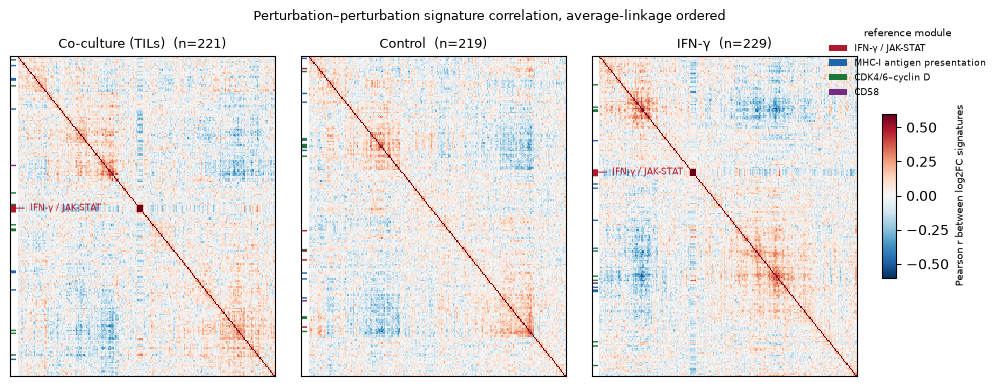

In [77]:
# correlation heatmap, average-linkage ordered, with reference modules as a colour strip
PAPER_CORE = json.load(open('data/pathway_labels_paper_core.json'))
MODCOL   = {'IFNG_JAK_STAT': '#b2182b', 'MHC_I_ANTIGEN_PRES': '#2166ac',
            'CDK4_6_CYCLIN_D': '#1b7837', 'CD58': '#762a83'}
MODSHORT = {'IFNG_JAK_STAT': 'IFN-γ / JAK-STAT', 'MHC_I_ANTIGEN_PRES': 'MHC-I antigen presentation',
            'CDK4_6_CYCLIN_D': 'CDK4/6–cyclin D', 'CD58': 'CD58'}

fig = plt.figure(figsize=(10.2, 4.1))
gs  = fig.add_gridspec(1, 3, wspace=0.10, left=0.03, right=0.86, top=0.84, bottom=0.06)
for j, c in enumerate(CONDS):
    ax = fig.add_subplot(gs[0, j])
    o  = leaves_list(linkage(squareform(Dmat[c], checks=False), method='average'))
    names = [R[c].index[i] for i in o]
    im = ax.imshow(R[c].values[np.ix_(o, o)], cmap='RdBu_r', vmin=-0.6, vmax=0.6,
                   interpolation='nearest', extent=[0, len(names), len(names), 0])
    ax.set_xticks([]); ax.set_yticks([])
    strip = np.zeros((len(names), 1, 4)); strip[:] = (1, 1, 1, 0)
    for i, g in enumerate(names):
        for mod, mem in PAPER_CORE.items():
            if g in mem:
                strip[i, 0] = mpl.colors.to_rgba(MODCOL[mod])
    ax.imshow(strip, extent=[-6, -1, len(names), 0], aspect='auto', zorder=5)
    ax.set_xlim(-6.5, len(names)); ax.set_ylim(len(names), 0)
    js = [i for i, g in enumerate(names) if g in PAPER_CORE['IFNG_JAK_STAT']]
    if js and (max(js) - min(js)) <= 6:
        ax.annotate('IFN-γ / JAK-STAT', xy=(-6, (min(js) + max(js)) / 2), xytext=(14, 0),
                    textcoords='offset points', fontsize=6.5, va='center', color=MODCOL['IFNG_JAK_STAT'],
                    arrowprops=dict(arrowstyle='-', lw=0.7, color=MODCOL['IFNG_JAK_STAT']), zorder=6)
    ax.set_title('%s  (n=%d)' % (CONDLAB[c], len(names)), fontsize=9)
cax = fig.add_axes([0.885, 0.30, 0.014, 0.40])
fig.colorbar(im, cax=cax).set_label('Pearson r between log2FC signatures', fontsize=7)
fig.legend(handles=[mpl.patches.Patch(fc=MODCOL[m], label=MODSHORT[m]) for m in PAPER_CORE],
           loc='lower right', bbox_to_anchor=(0.995, 0.72), frameon=False, fontsize=6.5,
           title='reference module', title_fontsize=7)
fig.suptitle('Perturbation–perturbation signature correlation, average-linkage ordered', fontsize=9, y=0.955)
fig.savefig('figures/task2_correlation_heatmap.png', dpi=300, bbox_inches='tight')

**Figure 4.** Signature correlation matrices, rows and columns ordered by average-linkage
dendrogram on 1 − r. Colour strip at the left of each panel marks reference-module membership
(Section 3). Diverging scale centred at r = 0.

## 3 Reference pathway labels

Ground truth for scoring is assembled from two sources, both recorded in the `source` column of
`data/pathway_labels.csv`:

* **`Frangieh2021_paper_module`** — the three programmes the paper discusses (IFN-γ–JAK/STAT
  signalling, MHC-I antigen presentation, CD58) plus the CDK4/6–cyclin D axis, entered manually
  from the publication.
* **`Reactome`** — pathway membership fetched per target from the Reactome ContentService HGNC
  mapping endpoint, then reduced to pathways with ≥ 5 members among the 248 targets.

Three targets present in a Reactome group (`UBA52`, `UBC`, `PPIA`) were removed: they belong to
dozens of pathways each, so their membership reflects annotation promiscuity rather than a
shared perturbation response.

**The labels cover 56 of 248 targets.** They are an incomplete reference, so ARI computed
against them is a lower bound: a cluster of genuinely co-functional targets that happen to be
unlabelled scores as disagreement.

In [78]:
# Reference labels are cached; the fetch that produced them is in section 3.1 below.
lab_df = pd.read_csv('data/pathway_labels.csv')
lab_df.groupby(['source', 'label']).perturbation.agg(n='size', members=lambda x: ', '.join(sorted(x)))

n  \
source                    label                        
Frangieh2021_paper_module CD58                     1   
                          CDK4_6_CYCLIN_D         10   
                          IFNG_JAK_STAT            5   
                          MHC_I_ANTIGEN_PRES       8   
Reactome                  IFNG_JAK_STAT            7   
                          LYSOSOMAL_CATHEPSIN      5   
                          MITO_RESPIRATION_TCA     8   
                          MRNA_SPLICING            7   
                          TRANSLATION_INITIATION   5   

                                                                                            members  
source                    label                                                                      
Frangieh2021_paper_module CD58                                                                 CD58  
                          CDK4_6_CYCLIN_D         CCND1, CCND2, CDK4, CDK6, CDKN1A, CDKN2A, CDKN...  
                          IFNG_JAK_STAT                           IFNGR1, IFNGR2, JAK1, JAK2, STAT1  
                          MHC_I_ANTIGEN_PRES      B2M, HLA-A, HLA-B, HLA-C, HLA-E, HLA-F, HLA-H,...  
Reactome                  IFNG_JAK_STAT             CD44, HLA-DRB5, IRF3, IRF4, MT2A, SP100, TRIM22  
                          LYSOSOMAL_CATHEPSIN                          CTSA, CTSB, CTSD, CTSL, CTSO  
                          MITO_RESPIRATION_TCA    CHCHD2, IDH2, MDH2, NDUFA13, SLC25A13, TIMM50,...  
                          MRNA_SPLICING           HNRNPA1, HNRNPC, PUF60, SNRPE, SNRPF, SNRPG, UBL5  
                          TRANSLATION_INITIATION                EIF2S3, EIF3K, EIF4A1, PABPC1, RPSA

In [79]:
LAB_FULL   = dict(zip(lab_df.perturbation, lab_df.label))
PAPER_ONLY = {g: l for l, v in PAPER_CORE.items() for g in v}
print('labelled targets: %d of 248 (%d in the paper modules)' % (len(LAB_FULL), len(PAPER_ONLY)))

labelled targets: 56 of 248 (24 in the paper modules)


### 3.1 How the Reactome labels were fetched

Run to regenerate; the result is already in `data/pathway_labels.csv`.

In [80]:
FETCH_REACTOME = False   # set True to re-fetch (248 sequential requests, ~2 min)

if FETCH_REACTOME:
    import requests
    from collections import Counter, defaultdict
    sess = requests.Session()
    react = {}
    for s in lf['Co_culture'].index:
        r = sess.get(f'https://reactome.org/ContentService/data/mapping/HGNC/{s}/pathways?species=9606',
                     timeout=30)
        react[s] = [(p['stId'], p['displayName']) for p in r.json()] if r.status_code == 200 else []
    members = defaultdict(set)
    for g, pws in react.items():
        for stid, name in pws:
            members[(stid, name)].add(g)
    big = {k: v for k, v in members.items() if len(v) >= 5}
    print('%d Reactome pathways with >=5 of the 248 targets' % len(big))

## 4 Scoring

Four measures per method and condition:

* **ARI / AMI vs the full 56-target reference**: external agreement over all labels.
* **ARI vs the paper modules only** (24 targets): the labels the paper's findings concern.
* **Silhouette on correlation distance**, noise points excluded, internal cohesion.
* **Bootstrap stability**: cells are resampled with replacement *within each perturbation
  group*, the log2FC matrix, gene selection and clustering are recomputed, and the mean pairwise
  ARI across 25 replicates is reported. This propagates cell-sampling noise, which is the
  dominant uncertainty in a pseudo-bulk signature.

Stability alone is a misleading criterion for a density method: DBSCAN reproduces the same
single cluster in every replicate and so scores 1.000 in the two immune conditions by being
degenerate. A fifth measure is therefore reported alongside — **core recovery rate**, the
fraction of replicates in which all five IFN-γ/JAK-STAT targets land together in one non-noise
cluster.

In [81]:
# Bootstrap cells within the same obs['perturbation'] groups used above.
# This propagates cell-sampling noise without ever clustering individual cells.
RUN_BOOTSTRAP = False   # True rebuilds every method; missing methods are refreshed automatically.
NB = 25
BOOT_DEFINITION = 'all_qc_cells_grouped_by_obs_perturbation_v1'

BOOT_FILE = 'data/task2_bootstrap_labels.pkl'
if RUN_BOOTSTRAP or not os.path.isfile(BOOT_FILE):
    boot = {c: {m: [] for m in METHODS} for c in CONDS}
    methods_to_run = list(METHODS)
else:
    _b = pd.read_pickle(BOOT_FILE)
    if _b.get('definition') != BOOT_DEFINITION:
        boot = {c: {m: [] for m in METHODS} for c in CONDS}
        methods_to_run = list(METHODS)
    else:
        boot, NB = _b['boot'], _b['NB']
        methods_to_run = [m for m in METHODS
                          if any(m not in boot.get(c, {}) or len(boot[c][m]) != NB for c in CONDS)]

if methods_to_run:
    UNION = sorted(set().union(*[set(gsel[c]) for c in CONDS]))
    X_boot = adata[:, UNION].X.tocsr()
    pert = adata.obs['perturbation'].astype(str).to_numpy()
    group_rows = {c: {p: np.flatnonzero(COND_MASK[c] & (pert == p))
                      for p in ['control'] + keep[c]} for c in CONDS}

    def bootstrap_signature(c, rng):
        rows = []
        for p in ['control'] + keep[c]:
            idx = group_rows[c][p]
            sample = rng.choice(idx, size=len(idx), replace=True)
            rows.append(np.asarray(X_boot[sample].mean(axis=0)).ravel())
        gm = pd.DataFrame(rows, index=['control'] + keep[c], columns=UNION)
        L = ((gm.drop(index='control') - gm.loc['control']) / np.log(2)).loc[keep[c], gsel[c]]
        Z = (L - L.mean(axis=0)) / L.std(axis=0).replace(0, np.nan)
        return Z.dropna(axis=1)

    for c in CONDS:
        boot.setdefault(c, {})
        for m in methods_to_run:
            boot[c][m] = []
        for b in range(NB):
            rng = np.random.default_rng(1000 + b)
            Zb = bootstrap_signature(c, rng)
            Db = 1.0 - np.corrcoef(Zb.values); np.fill_diagonal(Db, 0.0)
            clustered = cluster_all(Zb, Db, EPS[c], LEIDEN_RES[c])
            for m in methods_to_run:
                boot[c][m].append(clustered[m])
        print(c, 'refreshed:', ', '.join(methods_to_run))
    pd.to_pickle(dict(boot=boot, definition=BOOT_DEFINITION, eps_used=EPS,
                      leiden_resolution=LEIDEN_RES, NB=NB), BOOT_FILE)
print('%d bootstrap replicates per condition x method; refreshed %s' %
      (NB, methods_to_run or 'none (cache complete)'))

Co_culture refreshed: ward_euclid, average_corr, complete_corr, kmeans, leiden, dbscan, hdbscan
Control refreshed: ward_euclid, average_corr, complete_corr, kmeans, leiden, dbscan, hdbscan
IFNg refreshed: ward_euclid, average_corr, complete_corr, kmeans, leiden, dbscan, hdbscan
25 bootstrap replicates per condition x method; refreshed ['ward_euclid', 'average_corr', 'complete_corr', 'kmeans', 'leiden', 'dbscan', 'hdbscan']


In [82]:
from itertools import combinations

STAB = []
for c in CONDS:
    for m in METHODS:
        Ls = boot[c][m]
        STAB.append(dict(condition=c, method=m,
            stability_mean_pairwise_ari=np.mean([ARI(Ls[i].values, Ls[j].values)
                                                 for i, j in combinations(range(NB), 2)]),
            stability_vs_point_estimate=np.mean([ARI(labels[c][m].values, L.values) for L in Ls]),
            boot_mean_n_noise=float(np.mean([(L == -1).sum() for L in Ls])),
            boot_mean_n_clusters=float(np.mean([len(set(L) - {-1}) for L in Ls]))))
STAB = pd.DataFrame(STAB)

# core recovery: all five IFN-\u03b3/JAK-STAT targets in ONE non-noise cluster
core_rate = {}
for c in CONDS:
    for m in METHODS:
        hits = []
        for L in boot[c][m]:
            v = L.reindex(JS).dropna()
            hits.append(float(len(v) == 5 and v.nunique() == 1 and v.iloc[0] != -1))
        core_rate[(c, m)] = float(np.mean(hits))

STAB['core_recovery_rate'] = [core_rate[(r.condition, r.method)] for r in STAB.itertuples()]
STAB.round(3)

,condition,method,stability_mean_pairwise_ari,stability_vs_point_estimate,boot_mean_n_noise,boot_mean_n_clusters,core_recovery_rate
0,Co_culture,ward_euclid,0.125,0.152,0.00,8.00,1.00
1,Co_culture,average_corr,0.093,0.180,0.00,8.00,1.00
2,Co_culture,complete_corr,0.045,0.078,0.00,8.00,1.00
3,Co_culture,kmeans,0.119,0.167,0.00,8.00,1.00
4,Co_culture,leiden,0.124,0.249,0.00,2.32,1.00
5,Co_culture,dbscan,1.000,1.000,216.00,1.00,1.00
6,Co_culture,hdbscan,0.201,0.356,166.92,5.00,1.00
7,Control,ward_euclid,0.089,0.133,0.00,8.00,0.08
8,Control,average_corr,0.086,0.138,0.00,8.00,0.04
9,Control,complete_corr,0.034,0.052,0.00,8.00,0.00


In [83]:
def external_scores(s, ref, exclude_noise=False):
    ss = s[s != -1] if exclude_noise else s
    idx = [g for g in ss.index if g in ref]
    if len(idx) < 3 or len(set(ss.loc[idx])) < 2:
        return dict(n_labelled=len(idx), ari=np.nan, ami=np.nan)
    y = [ref[g] for g in idx]
    return dict(n_labelled=len(idx), ari=ARI(y, ss.loc[idx].values), ami=AMI(y, ss.loc[idx].values))

rows = []
for c in CONDS:
    for m, s in labels[c].items():
        nz = s.values != -1
        sil = (silhouette_score(Dmat[c][np.ix_(nz, nz)], s.values[nz], metric='precomputed')
               if nz.sum() > 2 and len(set(s.values[nz])) > 1 else np.nan)
        f, p, fn = (external_scores(s, LAB_FULL), external_scores(s, PAPER_ONLY),
                    external_scores(s, LAB_FULL, exclude_noise=True))
        rows.append(dict(condition=c, method=m,
                         n_clusters=len(set(s) - {-1}), n_noise=int((s == -1).sum()), silhouette=sil,
                         ari_full=f['ari'], ami_full=f['ami'], n_lab_full=f['n_labelled'],
                         ari_paper=p['ari'], ami_paper=p['ami'], n_paper=p['n_labelled'],
                         ari_full_nonoise=fn['ari'], n_full_nonoise=fn['n_labelled']))

COMP = pd.DataFrame(rows).merge(STAB, on=['condition', 'method'])
COMP['composite_paper_x_stability'] = COMP.ari_paper * COMP.stability_mean_pairwise_ari
COMP['eps_used'] = [EPS[c] for c in COMP.condition]
COMP.to_csv('data/clustering_comparison.csv', index=False)
COMP[['condition', 'method', 'ari_full', 'ami_full', 'ari_paper', 'silhouette',
      'stability_mean_pairwise_ari', 'core_recovery_rate', 'n_clusters', 'n_noise']].round(3)

,condition,method,ari_full,ami_full,ari_paper,silhouette,stability_mean_pairwise_ari,core_recovery_rate,n_clusters,n_noise
0,Co_culture,ward_euclid,0.113,0.178,0.418,-0.035,0.125,1.00,8,0
1,Co_culture,average_corr,0.073,0.154,0.213,0.035,0.093,1.00,8,0
2,Co_culture,complete_corr,0.088,0.141,0.198,0.020,0.045,1.00,8,0
3,Co_culture,kmeans,0.059,0.098,0.289,-0.046,0.119,1.00,8,0
4,Co_culture,leiden,0.032,0.068,0.021,0.073,0.124,1.00,2,0
5,Co_culture,dbscan,-0.003,0.084,0.368,NaN,1.000,1.00,1,216
6,Co_culture,hdbscan,0.041,0.154,0.360,0.242,0.201,1.00,3,182
7,Control,ward_euclid,0.143,0.161,0.231,-0.060,0.089,0.08,8,0
8,Control,average_corr,0.015,0.012,0.017,0.031,0.086,0.04,8,0
9,Control,complete_corr,0.085,0.108,0.029,0.008,0.034,0.00,8,0


Reading the table:

* `ari_full` reaches 0.143. Against the paper modules only (`ari_paper`) the maxima are
  0.418 / 0.231 / 0.371 for Co-culture / Control / IFN-γ.
* The five-gene IFN-γ/JAK-STAT core is recovered in every bootstrap by all seven methods in
  Co-culture and IFN-γ. Control recovery is 0–40 %, with 40 % for Leiden.
* Silhouette is negative for Ward and k-means, 0.068–0.078 for Leiden, and 0.210–0.283
  for HDBSCAN, which keeps
  only the dense parts.
* Leiden's mean pairwise bootstrap ARI is 0.124 / 0.128 / 0.166 for Co-culture / Control /
  IFN-γ; its coarse partition is moderately stable but agrees less well with the paper modules
  than Ward or k-means in the immune conditions.
* DBSCAN's stability of 1.000 in the two immune conditions reflects it returning the identical
  single 5-member cluster in all 25 replicates.

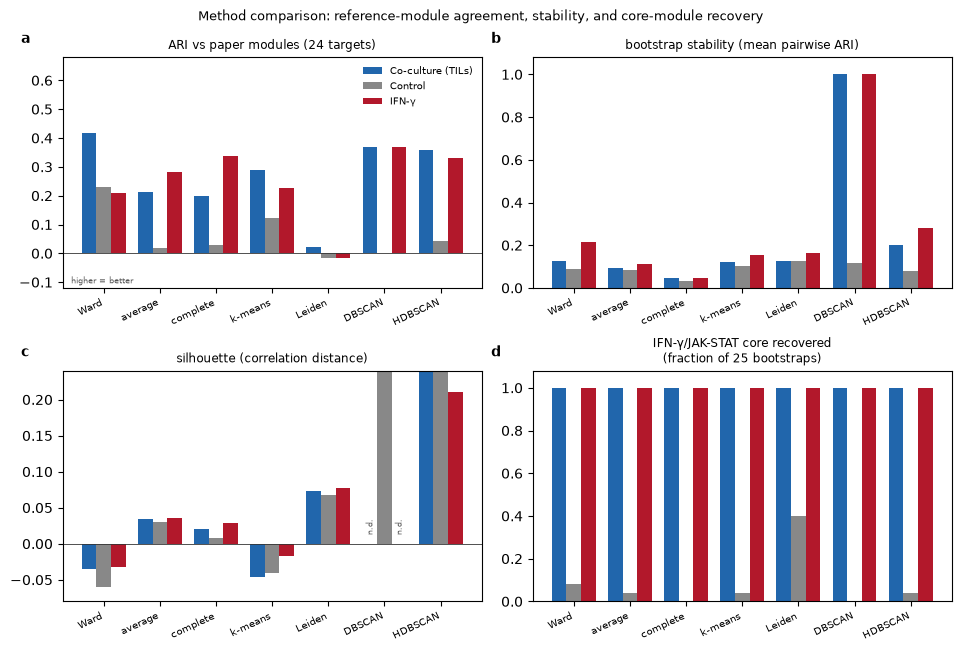

In [84]:
MSHORT = {'ward_euclid': 'Ward', 'average_corr': 'average', 'complete_corr': 'complete',
          'kmeans': 'k-means', 'leiden': 'Leiden', 'dbscan': 'DBSCAN', 'hdbscan': 'HDBSCAN'}
x, w = np.arange(len(METHODS)), 0.26
panels = [('ari_paper', 'ARI vs paper modules (24 targets)'),
          ('stability_mean_pairwise_ari', 'bootstrap stability (mean pairwise ARI)'),
          ('silhouette', 'silhouette (correlation distance)'),
          (None, 'IFN-\u03b3/JAK-STAT core recovered\n(fraction of 25 bootstraps)')]

fig, axes = plt.subplots(2, 2, figsize=(9.5, 6.4), constrained_layout=True)
axes = axes.ravel()
for ax, (col, title) in zip(axes, panels):
    for k, c in enumerate(CONDS):
        vals = (np.array([core_rate[(c, m)] for m in METHODS], dtype=float) if col is None
                else np.array([float(COMP[(COMP.condition == c) & (COMP.method == m)][col].iloc[0])
                               for m in METHODS], dtype=float))
        ax.bar(x + (k - 1) * w, np.nan_to_num(vals, nan=0.0), w, color=CCOL[c],
               label=CONDLAB[c] if ax is axes[0] else None)
        for xi, v in zip(x + (k - 1) * w, vals):
            if np.isnan(v):
                ax.annotate('n.d.', xy=(xi, 0.012), ha='center', va='bottom', fontsize=5.5,
                            rotation=90, color='#555555')
    ax.set_xticks(x); ax.set_xticklabels([MSHORT[m] for m in METHODS], rotation=25, ha='right', fontsize=7)
    ax.set_title(title, fontsize=8.5); ax.axhline(0, color='#333333', lw=0.6)
axes[0].set_ylim(-0.12, 0.68); axes[0].set_yticks([-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
axes[1].set_ylim(0, 1.08);     axes[1].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
axes[2].set_ylim(-0.08, 0.24); axes[2].set_yticks([-0.05, 0, 0.05, 0.10, 0.15, 0.20])
axes[3].set_ylim(0, 1.08);     axes[3].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
axes[0].legend(frameon=False, fontsize=7, loc='upper right')
axes[0].annotate('higher = better', xy=(0.02, 0.02), xycoords='axes fraction', fontsize=6, color='#555555')
for a_, l in zip(axes, 'abcd'):
    a_.annotate(l, xy=(0, 1), xycoords='axes fraction', xytext=(-30, 8), textcoords='offset points',
                fontweight='bold', fontsize=10, va='bottom')
fig.suptitle('Method comparison: reference-module agreement, stability, and core-module recovery', fontsize=9.5)
fig.savefig('figures/task2_method_comparison.png', dpi=300, bbox_inches='tight')

**Figure 5.** Method comparison. (a) ARI against the four paper modules, restricted to the 24
labelled targets. (b) Mean pairwise ARI across 25 bootstrap replicates. (c) Silhouette on
correlation distance, noise points excluded; `n.d.` where a single cluster makes it undefined.
(d) Fraction of replicates in which all five IFN-γ/JAK-STAT targets share one non-noise cluster.

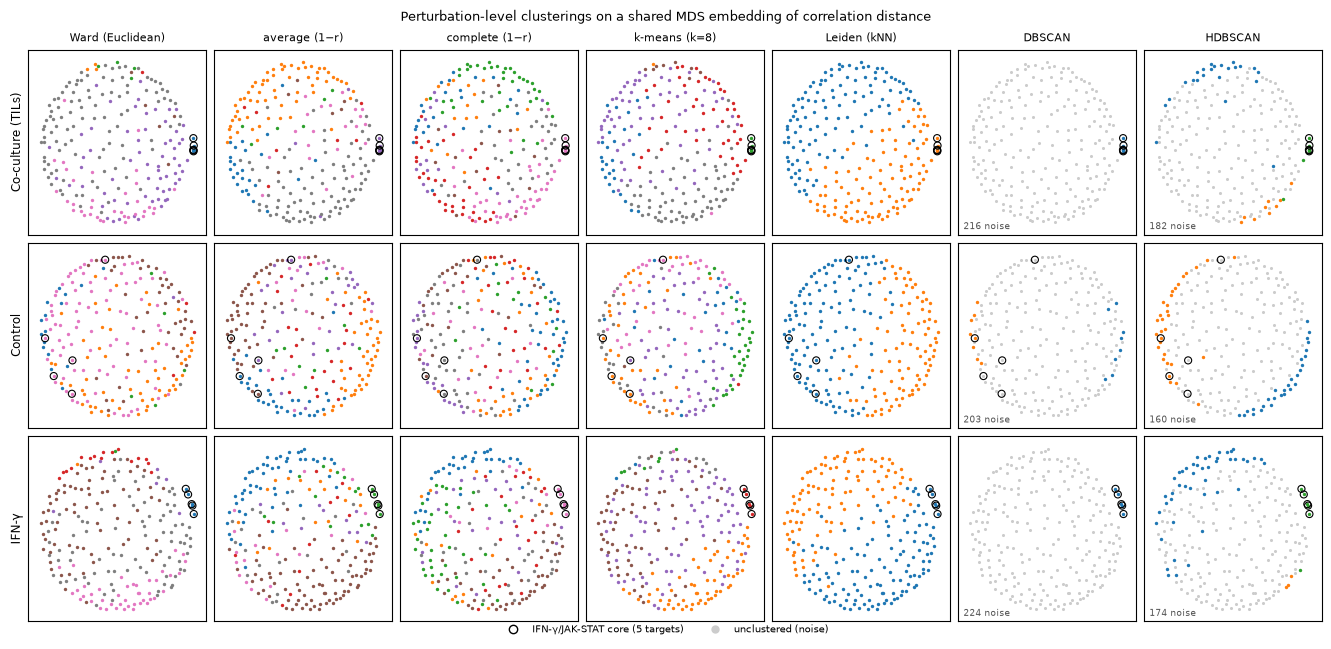

In [85]:
EMB = {c: MDS(n_components=2, metric='precomputed', random_state=7, init='random',
              normalized_stress='auto', n_init=4).fit_transform(Dmat[c]) for c in CONDS}

MLAB = {'ward_euclid': 'Ward (Euclidean)', 'average_corr': 'average (1\u2212r)',
        'complete_corr': 'complete (1\u2212r)', 'kmeans': 'k-means (k=8)', 'leiden': 'Leiden (kNN)',
        'dbscan': 'DBSCAN', 'hdbscan': 'HDBSCAN'}

fig, axes = plt.subplots(3, len(METHODS), figsize=(13.2, 6.2), constrained_layout=True)
for i, c in enumerate(CONDS):
    E = EMB[c]
    for j, m in enumerate(METHODS):
        ax = axes[i, j]; s = labels[c][m].values
        noise = s == -1
        ax.scatter(E[noise, 0], E[noise, 1], s=5, c='#cccccc', lw=0)
        cmap = plt.get_cmap('tab10')
        for k, cl in enumerate([v for v in sorted(set(s)) if v != -1]):
            mm = s == cl
            ax.scatter(E[mm, 0], E[mm, 1], s=6, color=cmap(k % 10), lw=0)
        js = [labels[c][m].index.get_loc(g) for g in JS if g in labels[c][m].index]
        ax.scatter(E[js, 0], E[js, 1], s=26, facecolors='none', edgecolors='black', lw=0.8, zorder=5)
        ax.set_xticks([]); ax.set_yticks([]); ax.margins(0.08)
        if i == 0: ax.set_title(MLAB[m], fontsize=8)
        if j == 0: ax.set_ylabel(CONDLAB[c], fontsize=8.5)
        if m in ('dbscan', 'hdbscan'):
            ax.annotate('%d noise' % noise.sum(), xy=(0.03, 0.03), xycoords='axes fraction',
                        fontsize=6.5, color='#555555')
fig.legend(handles=[plt.Line2D([], [], marker='o', ls='', mfc='none', mec='black', ms=6,
                               label='IFN-\u03b3/JAK-STAT core (5 targets)'),
                    plt.Line2D([], [], marker='o', ls='', color='#cccccc', ms=5,
                               label='unclustered (noise)')],
           loc='lower center', ncol=2, frameon=False, fontsize=7.5, bbox_to_anchor=(0.5, -0.03))
fig.suptitle('Perturbation-level clusterings on a shared MDS embedding of correlation distance', fontsize=9.5)
fig.savefig('figures/task2_method_embeddings.png', dpi=300, bbox_inches='tight')

**Figure 6.** All seven clusterings per condition, drawn on the same 2-D MDS embedding of the
correlation-distance matrix within each row so that colour differences are method differences,
not layout differences. Grey = noise. The MDS layout is a projection of a high-dimensional
distance matrix; between-point distances in the plane are approximate.

## 5 Factual observations

### 5.1 Module recovery per method and condition

In [86]:
def module_recovery(c, m):
    s = labels[c][m]
    rows = []
    for mod, mem in PAPER_CORE.items():
        mem = [g for g in mem if g in s.index]
        if not mem:
            continue
        best = max(((cl, len(set(s.index[s == cl]) & set(mem)) / len(set(s.index[s == cl]) | set(mem)),
                     len(set(s.index[s == cl]) & set(mem)), int((s == cl).sum()))
                    for cl in sorted(set(s) - {-1})), key=lambda t: (t[1], t[2]), default=(None, 0, 0, 0))
        rows.append(dict(condition=c, method=m, module=mod, n_members_present=len(mem),
                         best_cluster=best[0], jaccard=round(best[1], 3),
                         n_overlap=best[2], cluster_size=best[3],
                         n_noise_members=int((s.reindex(mem) == -1).sum())))
    return rows

MR = pd.DataFrame([r for c in CONDS for m in METHODS for r in module_recovery(c, m)])
MR.to_csv('data/module_recovery.csv', index=False)
MR.pivot_table(index=['module', 'method'], columns='condition', values='jaccard')

condition                         Co_culture  Control   IFNg
module             method                                   
CD58               average_corr        0.016    0.019  0.012
                   complete_corr       0.026    0.023  0.031
                   dbscan              0.000    0.000  0.000
                   hdbscan             0.043    0.000  0.000
                   kmeans              0.016    0.026  0.012
                   leiden              0.009    0.008  0.008
                   ward_euclid         0.010    0.062  0.012
CDK4_6_CYCLIN_D    average_corr        0.107    0.100  0.074
                   complete_corr       0.098    0.154  0.098
                   dbscan              0.000    0.200  0.000
                   hdbscan             0.118    0.152  0.083
                   kmeans              0.078    0.125  0.143
                   leiden              0.063    0.051  0.047
                   ward_euclid         0.138    0.111  0.083
IFNG_JAK_STAT      average_corr        0.625    0.062  0.278
                   complete_corr       0.109    0.065  0.385
                   dbscan              1.000    0.083  1.000
                   hdbscan             0.714    0.059  0.833
                   kmeans              1.000    0.073  1.000
                   leiden              0.046    0.040  0.039
                   ward_euclid         1.000    0.056  1.000
MHC_I_ANTIGEN_PRES average_corr        0.100    0.079  0.118
                   complete_corr       0.108    0.061  0.111
                   dbscan              0.000    0.000  0.000
                   hdbscan             0.000    0.059  0.000
                   kmeans              0.094    0.133  0.065
                   leiden              0.036    0.047  0.047
                   ward_euclid         0.059    0.091  0.062

In [87]:
# Which targets are called noise by the density methods, and how large are their effects?
eff = []
for c in CONDS:
    L, S = lf[c].loc[keep[c], gsel[c]].values, se[c].loc[keep[c], gsel[c]].values
    eff.append(pd.DataFrame({'perturbation': keep[c], 'condition': c,
                             'n_cells': ncells[c].loc[keep[c]].values,
                             'n_genes_z_gt3': (np.abs(L / S) > 3).sum(axis=1),
                             'mean_abs_log2fc': np.abs(L).mean(axis=1)}))
EFF = pd.concat(eff, ignore_index=True)

NT = pd.DataFrame({(c, m): (labels[c][m] == -1).astype(float)
                   for c in CONDS for m in ['dbscan', 'hdbscan']}).dropna()
noise_count = NT.sum(axis=1)          # 0..6 across 3 conditions x 2 density methods
E = EFF.pivot_table(index='perturbation', columns='condition', values='n_genes_z_gt3')
sub = pd.DataFrame({'noise_count': noise_count}).join(E).dropna()

pd.DataFrame({'n_targets': sub.groupby('noise_count').size(),
              **{'median_n_genes_z>3_' + c: sub.groupby('noise_count')[c].median() for c in CONDS}})

,n_targets,median_n_genes_z>3_Co_culture,median_n_genes_z>3_Control,median_n_genes_z>3_IFNg
noise_count,,,,
0.0,1,105.0,8.0,86.0
1.0,1,109.0,6.0,96.0
2.0,4,97.5,13.5,81.0
3.0,10,6.5,10.5,13.0
4.0,14,4.5,11.5,10.5
5.0,83,5.0,8.0,8.0
6.0,104,5.0,7.0,8.0


Targets called noise at most once have a median of 86–109 selected genes at
|log2FC|/SE > 3; targets called noise by both density methods in all three conditions have a
median of 5–8. The noise label tracks measured effect size.

Note the confound: `n_genes_z_gt3` depends on the number of cells behind each row, and the
correlation between `n_cells` and `n_genes_z_gt3` is 0.315 / −0.079 / 0.152 across the three
conditions. Low
statistical power and small biological effect are not separated by this measure.

In [88]:
sub.groupby('noise_count').size().rename('n_targets').to_frame().join(
    EFF.pivot_table(index='perturbation', columns='condition', values='n_cells')
       .join(pd.DataFrame({'noise_count': noise_count})).groupby('noise_count').median().round(0)
)

,n_targets,Co_culture,Control,IFNg
noise_count,,,,
0.0,1,522.0,247.0,337.0
1.0,1,597.0,213.0,384.0
2.0,4,396.0,200.0,278.0
3.0,10,236.0,212.0,310.0
4.0,14,236.0,186.0,282.0
5.0,83,233.0,173.0,271.0
6.0,104,234.0,178.0,271.0


In [89]:
print('never noise (0 of 6): ', ', '.join(sorted(sub.index[sub.noise_count == 0])))
print()
print('n targets by noise_count:', dict(sub.groupby('noise_count').size()))
print()
print('correlation n_cells vs n_genes_z_gt3:',
      {c: round(float(EFF[EFF.condition == c][['n_cells', 'n_genes_z_gt3']].corr().iloc[0, 1]), 3)
       for c in CONDS})

never noise (0 of 6):  JAK2

n targets by noise_count: {0.0: np.int64(1), 1.0: np.int64(1), 2.0: np.int64(4), 3.0: np.int64(10), 4.0: np.int64(14), 5.0: np.int64(83), 6.0: np.int64(104)}

correlation n_cells vs n_genes_z_gt3: {'Co_culture': 0.315, 'Control': -0.079, 'IFNg': 0.152}


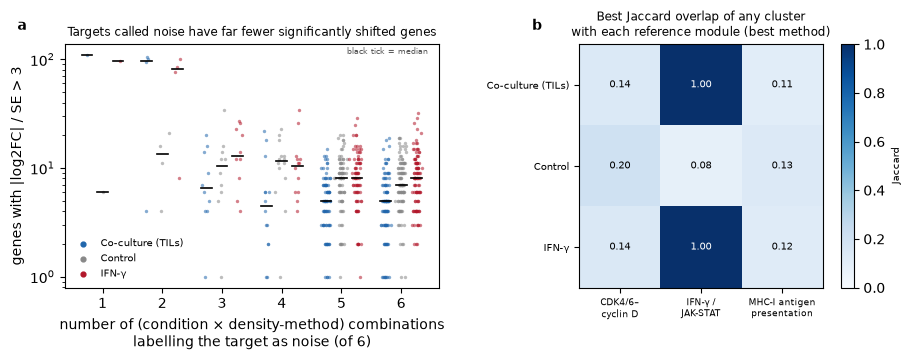

In [90]:
MODSHORT2 = {'IFNG_JAK_STAT': 'IFN-\u03b3 /\nJAK-STAT', 'MHC_I_ANTIGEN_PRES': 'MHC-I antigen\npresentation',
             'CDK4_6_CYCLIN_D': 'CDK4/6\u2013\ncyclin D', 'CD58': 'CD58'}

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.5), constrained_layout=True)

ax = axes[0]
jit = np.random.default_rng(0)
for k, c in enumerate(CONDS):
    for n in range(1, 7):
        v = sub[sub.noise_count == n][c].values
        if len(v) == 0:
            continue
        p = n + (k - 1) * 0.26
        ax.scatter(np.full(len(v), p) + jit.normal(0, 0.035, len(v)), v, s=6,
                   color=CCOL[c], alpha=0.55, lw=0)
        ax.plot([p - 0.09, p + 0.09], [np.median(v)] * 2, color='black', lw=1.2, zorder=5)
    ax.scatter([], [], s=12, color=CCOL[c], label=CONDLAB[c])
ax.set_yscale('log'); ax.set_xticks(range(1, 7))
ax.set_xlabel('number of (condition \u00d7 density-method) combinations\nlabelling the target as noise (of 6)')
ax.set_ylabel('genes with |log2FC| / SE > 3')
ax.legend(frameon=False, fontsize=7, loc='lower left')
ax.annotate('black tick = median', xy=(0.97, 0.96), xycoords='axes fraction', ha='right',
            fontsize=6, color='#555555')
ax.set_title('Targets called noise have far fewer significantly shifted genes', fontsize=8.5)

ax = axes[1]
mrc = MR[MR.module != 'CD58'].pivot_table(index='condition', columns='module', values='jaccard', aggfunc='max')
im = ax.imshow(mrc.values, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(mrc.shape[1]))
ax.set_xticklabels([MODSHORT2[m] for m in mrc.columns], rotation=0, ha='center', fontsize=6.5)
ax.set_yticks(range(len(mrc))); ax.set_yticklabels([CONDLAB[c] for c in mrc.index], fontsize=7.5)
for i in range(mrc.shape[0]):
    for j in range(mrc.shape[1]):
        v = mrc.values[i, j]
        ax.annotate('%.2f' % v, xy=(j, i), ha='center', va='center', fontsize=7,
                    color='white' if v > 0.5 else 'black')
ax.set_title('Best Jaccard overlap of any cluster\nwith each reference module (best method)', fontsize=8.5)
fig.colorbar(im, ax=ax, fraction=0.045).set_label('Jaccard', fontsize=7)
for a_, l in zip(axes, 'ab'):
    a_.annotate(l, xy=(0, 1), xycoords='axes fraction', xytext=(-34, 8), textcoords='offset points',
                fontweight='bold', fontsize=10, va='bottom')
fig.savefig('figures/task2_noise_and_module_recovery.png', dpi=300, bbox_inches='tight')

**Figure 7.** (a) Number of genes shifted at |log2FC|/SE > 3 per target, against how often the
two density methods called that target noise (217 targets present in all three conditions).
Log y axis. (b) Best Jaccard overlap between any single cluster and each reference module, taken
over the seven methods. CD58 is a one-member module and is omitted from (b).

### 5.2 Cluster membership in the chosen clustering

In [91]:
# Select the best non-degenerate method using the criterion reported below.
eligible = COMP[COMP.n_clusters > 1].sort_values(
    'composite_paper_x_stability', ascending=False)
best = eligible.iloc[0]
RECOMMENDED = (best.condition, best.method)
ALT_FOR_TASK3 = ('Co_culture', 'hdbscan')

s = labels[RECOMMENDED[0]][RECOMMENDED[1]]
pd.DataFrame([dict(cluster=int(cl), n=int((s == cl).sum()),
                   labelled_members=', '.join(sorted(g for g in s.index[s == cl] if g in LAB_FULL)) or '-',
                   first_members=', '.join(sorted(s.index[s == cl])[:10]))
              for cl in sorted(set(s) - {-1})])

,cluster,n,labelled_members,first_members
0,0,46,"CCND1, CD44, CDK4, CDK6, CKS1B, HNRNPC, MDH2, ...","ACSL3, BOLA2B, C1QBP, CCND1, CCR10, CD44, CD63..."
1,1,3,CDKN1A,"C19orf48, CDKN1A, EEA1"
2,2,6,"CDKN2B, IFNGR1, IFNGR2, JAK1, JAK2, STAT1","CDKN2B, IFNGR1, IFNGR2, JAK1, JAK2, STAT1"


In [92]:
# selection criterion: highest ARI(paper modules) x bootstrap stability, degenerate single-cluster excluded
COMP[COMP.n_clusters > 1].sort_values(
    'composite_paper_x_stability', ascending=False)[
    ['method', 'ari_paper', 'stability_mean_pairwise_ari', 'composite_paper_x_stability',
     'core_recovery_rate', 'n_clusters', 'n_noise', 'silhouette']].round(3)

,method,ari_paper,stability_mean_pairwise_ari,composite_paper_x_stability,core_recovery_rate,n_clusters,n_noise,silhouette
20,hdbscan,0.330,0.279,0.092,1.00,3,174,0.211
6,hdbscan,0.360,0.201,0.072,1.00,3,182,0.242
0,ward_euclid,0.418,0.125,0.052,1.00,8,0,-0.035
14,ward_euclid,0.210,0.213,0.045,1.00,8,0,-0.032
3,kmeans,0.289,0.119,0.035,1.00,8,0,-0.046
17,kmeans,0.226,0.152,0.034,1.00,8,0,-0.017
15,average_corr,0.282,0.114,0.032,1.00,8,0,0.035
7,ward_euclid,0.231,0.089,0.021,0.08,8,0,-0.060
1,average_corr,0.213,0.093,0.020,1.00,8,0,0.035
16,complete_corr,0.338,0.047,0.016,1.00,8,0,0.029


The recommended condition and method are selected directly from the regenerated comparison
table using paper-module ARI multiplied by bootstrap stability, excluding one-cluster
solutions. The exported provenance records the resulting choice and cluster sizes.

### 5.3 Genes underlying the perturbation clusters

The tables below use the same all-cell, `obs['perturbation']`-aggregated log2FC and SE
matrices used for clustering.

Two descriptive exports are produced:

* `perturbation_top_effects.parquet`: strongest up/down effects for every retained target,
  ranked by signed log2FC/SE within the selected signature genes.
* `cluster_effect_genes.csv`: top centroid effects and top contrasts against the other clusters
  for the recommended condition/method. These are descriptive ranks, not gene-level hypothesis
  tests; perturbations, are the replicates behind a cluster centroid.

In [93]:
def perturbation_effect_ranks(c, n_each=10):
    L = lf[c].loc[keep[c], gsel[c]]
    S = se[c].loc[keep[c], gsel[c]].clip(lower=1e-8)
    rows = []
    for p in L.index:
        z = L.loc[p] / S.loc[p]
        order = np.argsort(z.values)
        for direction, ix in [('down', order[:n_each]), ('up', order[-n_each:][::-1])]:
            for rank, j in enumerate(ix, 1):
                rows.append(dict(condition=c, perturbation=p, direction=direction, rank=rank,
                                 gene=L.columns[j], log2fc=float(L.iloc[L.index.get_loc(p), j]),
                                 se=float(S.iloc[S.index.get_loc(p), j]), z=float(z.iloc[j])))
    return pd.DataFrame(rows)

PERT_EFFECTS = pd.concat([perturbation_effect_ranks(c) for c in CONDS], ignore_index=True)
PERT_EFFECTS.to_parquet('data/perturbation_top_effects.parquet', index=False)
PERT_EFFECTS[PERT_EFFECTS.perturbation.isin(JS)].head(12)

,condition,perturbation,direction,rank,gene,log2fc,se,z
1900,Co_culture,IFNGR1,down,1,HLA-DPA1,-3.611733,0.115719,-31.211127
1901,Co_culture,IFNGR1,down,2,HLA-DRA,-4.181654,0.136797,-30.568217
1902,Co_culture,IFNGR1,down,3,HLA-DRB1,-4.074079,0.138269,-29.464880
1903,Co_culture,IFNGR1,down,4,CD74,-4.516488,0.158431,-28.507638
1904,Co_culture,IFNGR1,down,5,HLA-DMA,-2.175925,0.096309,-22.593075
1905,Co_culture,IFNGR1,down,6,HLA-B,-2.666173,0.120404,-22.143649
1906,Co_culture,IFNGR1,down,7,HLA-DPB1,-2.489721,0.112769,-22.077969
1907,Co_culture,IFNGR1,down,8,IDO1,-1.084357,0.051988,-20.857703
1908,Co_culture,IFNGR1,down,9,GBP1,-2.804944,0.141421,-19.833987
1909,Co_culture,IFNGR1,down,10,WARS,-2.792184,0.142152,-19.642174


In [94]:
def cluster_effect_ranks(c, m, n_each=8):
    s = labels[c][m]
    s = s[s != -1]
    L = lf[c].loc[s.index, gsel[c]]
    rows = []
    for cl in sorted(set(s)):
        members = list(s.index[s == cl]); others = list(s.index[s != cl])
        centroid = L.loc[members].mean(axis=0)
        contrast = centroid - (L.loc[others].mean(axis=0) if others else 0.0)
        for rank_type, score in [('centroid', centroid), ('contrast', contrast)]:
            order = np.argsort(score.values)
            for direction, ix in [('down', order[:n_each]), ('up', order[-n_each:][::-1])]:
                for rank, j in enumerate(ix, 1):
                    rows.append(dict(condition=c, method=m, cluster=int(cl), n_members=len(members),
                                     rank_type=rank_type, direction=direction, rank=rank, gene=L.columns[j],
                                     centroid_log2fc=float(centroid.iloc[j]),
                                     contrast_vs_other_clusters=float(contrast.iloc[j])))
    return pd.DataFrame(rows)

CLUSTER_EFFECTS = cluster_effect_ranks(*RECOMMENDED)
CLUSTER_EFFECTS.to_csv('data/cluster_effect_genes.csv', index=False)
CLUSTER_EFFECTS[CLUSTER_EFFECTS.rank_type == 'centroid'].head(16)

,condition,method,cluster,n_members,rank_type,direction,rank,gene,centroid_log2fc,contrast_vs_other_clusters
0,IFNg,hdbscan,0,46,centroid,down,1,MSMP,-0.132357,0.177819
1,IFNg,hdbscan,0,46,centroid,down,2,CXCL10,-0.129169,0.537808
2,IFNg,hdbscan,0,46,centroid,down,3,IGFBP3,-0.112489,-0.193608
3,IFNg,hdbscan,0,46,centroid,down,4,PEG10,-0.109776,-0.553369
4,IFNg,hdbscan,0,46,centroid,down,5,AREG,-0.109104,-0.149383
5,IFNg,hdbscan,0,46,centroid,down,6,CXCL11,-0.104775,0.670917
6,IFNg,hdbscan,0,46,centroid,down,7,CCNB2,-0.091423,-0.556453
7,IFNg,hdbscan,0,46,centroid,down,8,LRRC17,-0.086040,-0.770437
8,IFNg,hdbscan,0,46,centroid,up,1,GBP2,0.167531,1.995055
9,IFNg,hdbscan,0,46,centroid,up,2,HSPA5,0.163697,-0.025692


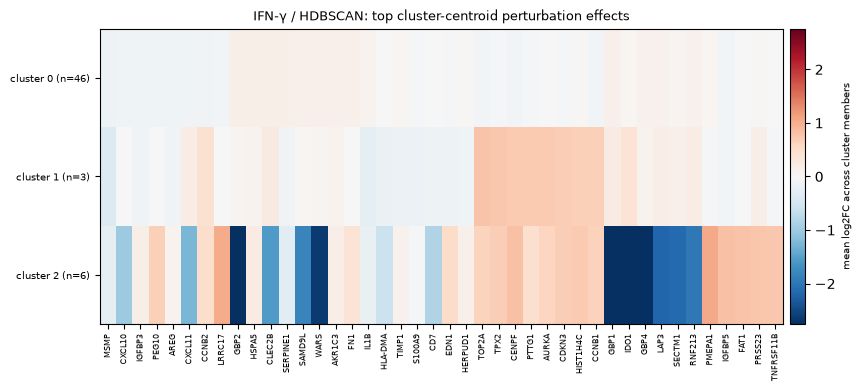

In [95]:
# Compact view of the strongest centroid effects; labels show why clusters separate.
ce = CLUSTER_EFFECTS[CLUSTER_EFFECTS.rank_type == 'centroid']
show_genes = list(dict.fromkeys(ce.sort_values(['cluster', 'direction', 'rank']).gene))
srec = labels[RECOMMENDED[0]][RECOMMENDED[1]]
centroids = pd.DataFrame({int(cl): lf[RECOMMENDED[0]].loc[srec.index[srec == cl], show_genes].mean()
                          for cl in sorted(set(srec) - {-1})}).T
lim = max(0.1, float(np.nanpercentile(np.abs(centroids.values), 98)))
fig, ax = plt.subplots(figsize=(max(8.5, 0.18 * len(show_genes)), 3.8), constrained_layout=True)
im = ax.imshow(centroids.values, aspect='auto', cmap='RdBu_r', vmin=-lim, vmax=lim)
ax.set_yticks(range(len(centroids))); ax.set_yticklabels(['cluster %s (n=%d)' %
    (cl, int((srec == cl).sum())) for cl in centroids.index], fontsize=7)
ax.set_xticks(range(len(show_genes))); ax.set_xticklabels(show_genes, rotation=90, fontsize=5.5)
ax.set_title('%s / %s: top cluster-centroid perturbation effects' %
             (CONDLAB[RECOMMENDED[0]], MSHORT[RECOMMENDED[1]]), fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01).set_label('mean log2FC across cluster members', fontsize=7)
fig.savefig('figures/task2_cluster_effect_heatmap.png', dpi=300, bbox_inches='tight')

**Figure 8.** Mean log2FC of the strongest up/down centroid genes for every cluster in the
recommended perturbation-level partition. Gene ranks and the contrast against all other clusters are
available in `data/cluster_effect_genes.csv`; the full per-target ranks are stored separately.

In [96]:
export = pd.DataFrame([
    dict(perturbation=g, condition=c, method=m, cluster=int(v), is_noise=bool(v == -1),
         n_cells=int(ncells[c].loc[g]))
    for c in CONDS for m in METHODS for g, v in labels[c][m].items()])
export['pathway_label']     = export.perturbation.map(LAB_FULL)
export['paper_module']      = export.perturbation.map(PAPER_ONLY)
export['recommended']       = (export.condition == RECOMMENDED[0])  & (export.method == RECOMMENDED[1])
export['task3_usable_group']= ((export.condition == ALT_FOR_TASK3[0]) & (export.method == ALT_FOR_TASK3[1])
                               & ~export.is_noise)
export.to_parquet('data/perturbation_clusters.parquet', index=False)

provenance = dict(
    recommended_condition=RECOMMENDED[0], recommended_method=RECOMMENDED[1],
    criterion='max ARI(paper modules) x bootstrap stability among non-degenerate methods (n_clusters>1)',
    ari_paper=float(COMP[(COMP.condition == RECOMMENDED[0]) & (COMP.method == RECOMMENDED[1])].ari_paper.iloc[0]),
    stability=float(COMP[(COMP.condition == RECOMMENDED[0]) &
                         (COMP.method == RECOMMENDED[1])].stability_mean_pairwise_ari.iloc[0]),
    min_cells_per_perturbation=MIN_CELLS, n_genes_per_condition={c: len(gsel[c]) for c in CONDS},
    n_perturbations={c: len(keep[c]) for c in CONDS},
    dbscan_eps={c: round(EPS[c], 4) for c in CONDS},
    leiden_knn=LEIDEN_KNN, leiden_resolution={c: float(LEIDEN_RES[c]) for c in CONDS},
    best_k_by_silhouette={c: int(BEST_K_SIL[c]) for c in CONDS},
    k_hierarchical_and_kmeans=K_PART, hdbscan_min_cluster_size=MIN_CLUSTER_SIZE,
    dbscan_min_samples=MIN_SAMPLES, n_bootstraps=NB,
    aggregation="all QC-passing cells grouped by obs['perturbation'] within condition",
    control="same-condition obs['perturbation'] == 'control' aggregate",
    feature_space='dataset_hv.h5ad log1p matrix',
    effect_interpretation=dict(genes='up to 750 expressed non-mitochondrial genes per condition',
                               per_perturbation_rank='signed log2FC / SE',
                               cluster_rank='centroid log2FC and contrast vs other clusters'),
    dropped_promiscuous_labels=['UBA52', 'UBC', 'PPIA'],
    alt_for_task3=dict(condition=ALT_FOR_TASK3[0], method=ALT_FOR_TASK3[1],
                       cluster_sizes={int(k): int(v) for k, v in
                                      labels[ALT_FOR_TASK3[0]][ALT_FOR_TASK3[1]]
                                      .pipe(lambda s: s[s != -1].value_counts()).items()}),
    task3_note=('The task3_usable_group flag retains the Co-culture HDBSCAN non-noise groups; '
                'Task 3 does not use this table as a modelling input.'))
json.dump(provenance, open('data/perturbation_clusters_provenance.json', 'w'), indent=2)

print('%d rows exported to data/perturbation_clusters.parquet' % len(export))

4683 rows exported to data/perturbation_clusters.parquet
